Шаг 1:
Используются источники из первой ДЗ + 10 вопросов без ответа
По ним выполнялся fetch_corpus.py

Шаг 2

In [22]:
import os, re, sys, json, time, hashlib, threading
from pathlib import Path
from dataclasses import dataclass, field
from concurrent.futures import ThreadPoolExecutor
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pydantic import BaseModel, Field
from pymilvus import MilvusClient

try:
    from dotenv import load_dotenv
    load_dotenv()
except ImportError:
    pass
try:
    from kaggle_secrets import UserSecretsClient
    os.environ.setdefault("OPENROUTER_API_KEY", UserSecretsClient().get_secret("OPENROUTER_API_KEY"))
except Exception:
    pass
assert os.getenv("OPENROUTER_API_KEY"), "нет ключа: положите его в .env рядом с ноутбуком или в Kaggle Secrets"

CHAT_URL = "https://openrouter.ai/api/v1/chat/completions"
EMBED_URL = "https://openrouter.ai/api/v1/embeddings"
HEADERS = {"Authorization": f"Bearer {os.environ['OPENROUTER_API_KEY']}", "X-Title": "agents-course-seminar02"}
MODELS = {"cheap": "openai/gpt-4o-mini", "mid": "anthropic/claude-haiku-4.5", "strong": "anthropic/claude-sonnet-4.6"}
EMBED_MODEL, DIM = "openai/text-embedding-3-small", 512
COLORS = {"violet": "#5436A3", "amber": "#F09000", "teal": "#00838F", "red": "#C43C3C", "grey": "#787882"}
DATA = next((p for p in [Path("data"), Path("/kaggle/input/seminar02-data"), Path("/kaggle/input/seminar02-data/data")]
             if (p / "corpus_2026.jsonl").exists()), Path("data"))
Path("img").mkdir(exist_ok=True)


@dataclass
class Ledger:
    calls: list = field(default_factory=list)
    local: threading.local = field(default_factory=threading.local)

    def add(self, tag, model, usage, seconds=0.0):
        cost = usage.get("cost") or 0.0
        self.calls.append({"tag": tag, "model": model.split("/")[-1], "prompt": usage.get("prompt_tokens", 0),
                           "completion": usage.get("completion_tokens", 0), "cost": cost, "seconds": round(seconds, 2)})
        self.local.spent = self.mine + cost
        return cost

    @property
    def total(self):
        return sum(c["cost"] for c in self.calls)

    @property
    def mine(self):
        return getattr(self.local, "spent", 0.0)

    def table(self):
        frame = pd.DataFrame(self.calls, columns=["tag", "model", "prompt", "completion", "cost", "seconds"])
        return frame.groupby(["tag", "model"]).agg(calls=("cost", "size"), prompt=("prompt", "sum"),
                                                                      completion=("completion", "sum"), cost=("cost", "sum")).round(5)


ledger = Ledger()


def post_with_retry(url, body, attempts=5):
    problem = "нет ответа"
    for attempt in range(attempts):
        try:
            r = requests.post(url, json=body, headers=HEADERS, timeout=120)
            if r.status_code == 200:
                return r.json()
            problem = f"HTTP {r.status_code}: {r.text[:200]}"
            if r.status_code not in (429, 500, 502, 503, 504):
                break
        except requests.RequestException as e:
            problem = type(e).__name__
        time.sleep(2.0 * (attempt + 1))
    raise RuntimeError(problem)


def chat(messages, model, tools=None, tag="chat"):
    body = {"model": model, "messages": messages, "temperature": 0, "usage": {"include": True}}
    if tools:
        body["tools"] = tools
    started = time.perf_counter()
    data = post_with_retry(CHAT_URL, body)
    ledger.add(tag, model, data.get("usage") or {}, time.perf_counter() - started)
    return data["choices"][0]["message"]


def load_jsonl(name):
    return [json.loads(line) for line in (DATA / name).read_text(encoding="utf-8").splitlines() if line.strip()]

In [23]:
%pip install -q requests pydantic python-dotenv pandas matplotlib numpy pymilvus pypdf

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [24]:
corpus, tasks = load_jsonl("corpus_2026.jsonl"), load_jsonl("fresh_2026.jsonl")
len(corpus), sum(len(p["text"]) for p in corpus), len(tasks), tasks[0]

(29,
 871787,
 155,
 {'id': 'fresh-0',
  'source': 'fresh',
  'question': 'On what date did Ukraine boycott the closing ceremony of the 2026 Winter Paralympics?',
  'answer': '15 March',
  'evidence': '15 March – Ukraine boycotts the closing ceremony of the 2026 Winter Paralympics in Italy in protest over Russian athletes being allowed to compete under the Russian flag after the lifting of sanctions imposed over the Russian invasion in 2022.',
  'page': '2026 in Ukraine',
  'url': 'https://en.wikipedia.org/wiki/2026_in_Ukraine',
  'sonnet_answer': 'unknown',
  'agent_ok': False})

In [25]:
def chunk_lines(page):
    chunks, section = [], ""
    for line in page["text"].splitlines():
        line = " ".join(line.split())
        if line.startswith("="):
            section = line.strip('= ') #граница куска
        elif len(line) > 40:
            chunks.append({"page": page["page"], "section": section, "url" : page["url"], "text": line})
    return chunks

### Осмысленная нарезка
Нарежем текст **по строкам, сохраняя заголовки разделов как метаданные**:
граница куска проходит там, где заканчивается одна строка-факт и начинается другая
(каждая строка Wikipedia-статьи это одно событие с датой). Это не режет факт
пополам, в отличие от наивной нарезки по 400 символам, и даёт модели цельный
контекст для ответа.

In [26]:
#наивная нарезка
def chunk_chars(page, size=400):
    text = " ".join(page["text"].split())
    return [{"page": page["page"], "section": "", "url": page["url"], "text": text[i:i + size]} for i in range(0, len(text), size)]

line_chunks = [c for p in corpus for c in chunk_lines(p)]
char_chunks = [c for p in corpus for c in chunk_chars(p)]
len(line_chunks), len(char_chunks), line_chunks[100]

(6016,
 2184,
 {'page': '2026',
  'section': 'April',
  'url': 'https://en.wikipedia.org/wiki/2026',
  'text': 'April 13 – 2026 Iran war: A blockade of Iranian ports by the United States takes effect, with President Trump warning that any Iranian vessels attempting to challenge it will be "immediately eliminated". Maritime authorities advise ships in the region to expect increased military activity and possible interception procedures.'})

In [27]:
def torn(task):
    words = re.findall(r"\w+", task["evidence"].lower())
    head, tail = " ".join(words[:6]), " ".join(words[-6:])
    parts = [c["text"] for c in char_chunks if c["page"] == task["page"]
             and (head in " ".join(re.findall(r"\w+", c["text"].lower())) or tail in " ".join(re.findall(r"\w+", c["text"].lower())))]
    return parts if len(parts) == 2 else None

example = next(t for t in tasks if torn(t))
print("вопрос:", example["question"], "| ответ:", example["answer"])
for n, part in enumerate(torn(example), 1):
    print(f"кусок {n}: ...{part[-160:]}" if n == 1 else f"кусок {n}: {part[:160]}...")

вопрос: On what date did Ukraine boycott the closing ceremony of the 2026 Winter Paralympics? | ответ: 15 March
кусок 1: ...ic partnership agreement in the defense and energy sectors. 15 March – Ukraine boycotts the closing ceremony of the 2026 Winter Paralympics in Italy in protest 
кусок 2: over Russian athletes being allowed to compete under the Russian flag after the lifting of sanctions imposed over the Russian invasion in 2022. 19 March – Forme...


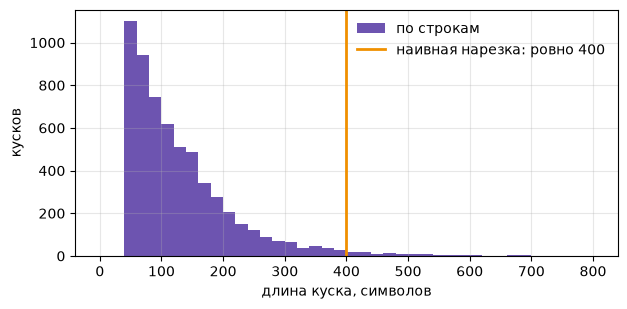

In [28]:
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.hist([len(c["text"]) for c in line_chunks], bins=40, range=(0, 800), color=COLORS["violet"], alpha=0.85, label="по строкам")
ax.axvline(400, color=COLORS["amber"], lw=2, label="наивная нарезка: ровно 400")
ax.set_xlabel("длина куска, символов"); ax.set_ylabel("кусков"); ax.legend(frameon=False); ax.grid(alpha=0.3);

Эмбеддинги с кэшем на диске: повторный запуск ноутбука не должен платить за те же тексты второй раз

In [29]:
EMB = {}

def load_cache():
    for path in [DATA / "embeddings_512.npz", Path("emb_cache.npz")]:
        if path.exists():
            z = np.load(path)
            EMB.update({str(k): v.astype(np.float32) for k, v in zip(z["keys"], z["vectors"])})
    return len(EMB)

def save_cache():
    np.savez_compressed("emb_cache.npz", keys=np.array(list(EMB)), vectors=np.stack(list(EMB.values())).astype(np.float16))

def embed_batch(texts):
    started = time.perf_counter()
    data = post_with_retry(EMBED_URL, {"model": EMBED_MODEL, "input": texts, "dimensions": DIM})
    ledger.add("embed", EMBED_MODEL, data.get("usage") or {}, time.perf_counter() - started)
    return [row["embedding"] for row in data["data"]]

def key_of(text):
    return hashlib.sha1(text.encode("utf-8")).hexdigest()

load_cache()

8323

In [30]:
def embed_cached(texts):
    missing = list(dict.fromkeys(t for t in texts if key_of(t) not in EMB)) #set нельзя т.к. нет порядка
    for i in range(0, len(missing), 64):
        batch = missing[i:i+64]
        for text, vector in zip(batch, embed_batch(batch)):
            EMB[key_of(text)] = np.asarray(vector, dtype=np.float32)

    vectors = np.stack([EMB[key_of(t)] for t in texts])
    return vectors / np.linalg.norm(vectors, axis=1, keepdims=True)
        


In [32]:
def emb_text(chunk):
    return f"{chunk['page']}: {chunk['text']}"

line_vecs = embed_cached([emb_text(c) for c in line_chunks])
char_vecs = embed_cached([c["text"] for c in char_chunks])
q_vecs = embed_cached([t["question"] for t in tasks])
save_cache()
line_vecs.shape, char_vecs.shape, q_vecs.shape

((6016, 512), (2184, 512), (155, 512))

## Поиск на numpy и recall@k

In [33]:
def search_numpy(query_vec, vectors, k=5):
    sims = vectors @ query_vec
    top = np.argsort(-sims)[:k]
    return[(int(i), float(sims[i])) for i in top]


In [34]:
NUMBERS = {word: str(n) for n, word in enumerate("zero one two three four five six seven eight nine ten eleven twelve".split())}

def norm(text):
    words = re.sub(r"\b(a|an|the)\b|[^\w\s]", " ", str(text).lower()).split()
    return " ".join(NUMBERS.get(w, w) for w in words)

def is_gold(chunk, task):
    if chunk["page"] != task["page"]:
        return False
    text, words = norm(chunk["text"]), norm(task["evidence"]).split()
    return norm(task["answer"]) in text and sum(w in text for w in words) >= 0.5 * len(words)

def recall_curve(chunks, vectors, ks=(1, 3, 5, 10)):
    ranked = [[i for i, _ in search_numpy(q, vectors, max(ks))] for q in q_vecs]
    return {k: float(np.mean([any(is_gold(chunks[i], t) for i in r[:k]) for r, t in zip(ranked, tasks)])) for k in ks}

for i, score in search_numpy(q_vecs[0], line_vecs, 3):
    print(round(score, 3), "|", line_chunks[i]["page"], "|", line_chunks[i]["text"][:110])
tasks[0]["question"], tasks[0]["answer"]

0.821 | 2026 in Ukraine | 15 March – Ukraine boycotts the closing ceremony of the 2026 Winter Paralympics in Italy in protest over Russi
0.803 | 2026 in Ukraine | Ukraine boycotts the opening ceremony of the 2026 Winter Paralympics in Italy in protest over Russian athletes
0.674 | 2026 in Ukraine | 6–22 February – Ukraine at the 2026 Winter Olympics


('On what date did Ukraine boycott the closing ceremony of the 2026 Winter Paralympics?',
 '15 March')

### Кривая recall@k для k = 1, 3, 5, 10 по обоим нарезкам

,по строкам,по 400 символов
1,0.81,0.48
3,0.90,0.66
5,0.91,0.73
10,0.91,0.76


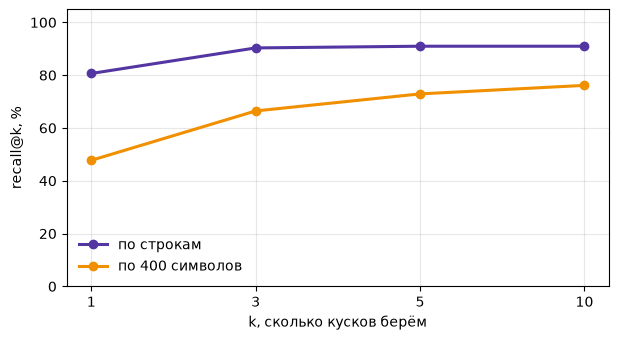

In [35]:
curves = {"по строкам": recall_curve(line_chunks, line_vecs), "по 400 символов": recall_curve(char_chunks, char_vecs)}
fig, ax = plt.subplots(figsize=(7, 3.6))
for (name, curve), color in zip(curves.items(), [COLORS["violet"], COLORS["amber"]]):
    ax.plot([str(k) for k in curve], [v * 100 for v in curve.values()], marker="o", lw=2.2, color=color, label=name)
ax.set_xlabel("k, сколько кусков берём"); ax.set_ylabel("recall@k, %"); ax.set_ylim(0, 105); ax.legend(frameon=False); ax.grid(alpha=0.3)
fig.savefig("img/recall.png", dpi=150, bbox_inches="tight")
pd.DataFrame(curves).round(2)

### Выбор k
Выбор **k=5**: при переходе с k=3 на k=5 recall@k растёт с 0.90 до 0.91 (+1 п.п.),
а дальнейший рост до k=10 не даёт прироста (0.91 → 0.91), но увеличивает стоимость
вопроса почти в 1.5 раза.

## Milvus

In [36]:
MILVUS_URI = os.getenv("MILVUS_URI", "http://localhost:19530")
client = MilvusClient(uri=MILVUS_URI, token=os.getenv("MILVUS_TOKEN", ""))
if os.getenv("MILVUS_DB"):
    if os.environ["MILVUS_DB"] not in client.list_databases():
        client.create_database(os.environ["MILVUS_DB"])
    client.use_database(os.environ["MILVUS_DB"])
client.get_server_version(), client.list_collections()

('2.6.24', ['lines'])

In [37]:
def index_to_milvus(name, chunks, vectors):
    if client.has_collection(name):
        client.drop_collection
    client.create_collection(name, dimension=vectors.shape[1], metric_type="COSINE")
    rows = [{"id": i, "vector": v.tolist(), **c} for i, (c, v) in enumerate(zip(chunks, vectors))]
    for i in range(0, len(rows), 1000):
        client.insert(name, rows[i:i+1000])

    client.flush(name)
    return client.get_collection_stats(name)
    


In [38]:
def search_milvus(name, query, k=5, flt=""):
    vector = embed_cached([query])[0].tolist()
    hits = client.search(name, data=[vector], limit=k, filter=flt, output_fields=["page", "section", "url", "text"])[0]

    return [{**h['entity'], "id": h["id"], "score": round(h["distance"], 4)} for h in hits ]
    


In [39]:
index_to_milvus("lines", line_chunks, line_vecs), client.describe_index("lines", "vector")

({'row_count': 12032},
 {'index_type': 'AUTOINDEX',
  'metric_type': 'COSINE',
  'field_name': 'vector',
  'index_name': 'vector',
  'total_rows': 12032,
  'indexed_rows': 6016,
  'pending_index_rows': 6016,
  'state': 'InProgress'})

In [40]:
pd.DataFrame(search_milvus("lines", tasks[0]["question"], 3))[["score", "page", "section", "text"]]

,score,page,section,text
0,0.8213,2026 in Ukraine,March,15 March – Ukraine boycotts the closing ceremo...
1,0.8033,2026 in Ukraine,March,Ukraine boycotts the opening ceremony of the 2...
2,0.6743,2026 in Ukraine,February,6–22 February – Ukraine at the 2026 Winter Oly...


In [41]:
from_numpy = [[i for i, _ in search_numpy(q, line_vecs, 5)] for q in q_vecs]
from_milvus = [[h["id"] for h in hits] for hits in client.search("lines", data=q_vecs.tolist(), limit=5)]
overlap = float(np.mean([len(set(a) & set(b)) / 5 for a, b in zip(from_numpy, from_milvus)]))
round(overlap, 3), sum(a == b for a, b in zip(from_numpy, from_milvus)), len(q_vecs)

(0.995, 150, 155)

In [42]:
pd.DataFrame(search_milvus("lines", "earthquake magnitude", 5, 'page == "2026 in Japan"'))[["score", "page", "section", "text"]]

,score,page,section,text
0,0.4603,2026 in Japan,April,April 20 – A magnitude 7.7 earthquake hits off...
1,0.4578,2026 in Japan,May,May 15 – A magnitude 6.3 earthquake strikes of...
2,0.4551,2026 in Japan,May,A magnitude 5.9 earthquake strikes southern Am...
3,0.4351,2026 in Japan,April,A magnitude 5.0 earthquake hits southern Tochi...
4,0.4287,2026 in Japan,April,April 27 – A magnitude 6.1 earthquake strikes ...


{'numpy, перебор': 0.72,
 'Milvus, запрос на вызов': 3.03,
 'Milvus, сто запросов пачкой': 0.09}

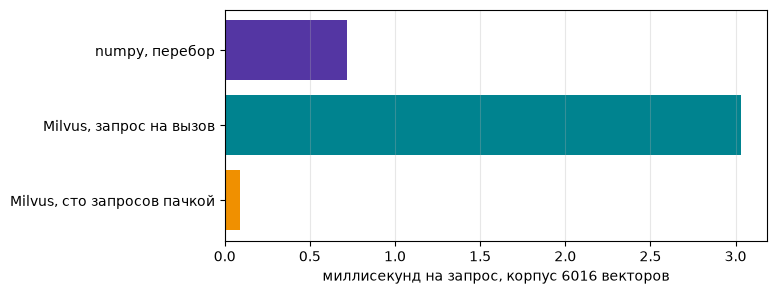

In [43]:
def per_query_ms(fn, n=100):
    started = time.perf_counter()
    fn()
    return (time.perf_counter() - started) * 1000 / n

queries = q_vecs[:100]
speed = {"numpy, перебор": per_query_ms(lambda: [search_numpy(q, line_vecs, 5) for q in queries]),
         "Milvus, запрос на вызов": per_query_ms(lambda: [client.search("lines", data=[q.tolist()], limit=5) for q in queries]),
         "Milvus, сто запросов пачкой": per_query_ms(lambda: client.search("lines", data=queries.tolist(), limit=5))}
fig, ax = plt.subplots(figsize=(7, 3))
ax.barh(list(speed), list(speed.values()), color=[COLORS["violet"], COLORS["teal"], COLORS["amber"]])
ax.invert_yaxis(); ax.set_xlabel(f"миллисекунд на запрос, корпус {len(line_vecs)} векторов"); ax.grid(alpha=0.3, axis="x")
{name: round(ms, 2) for name, ms in speed.items()}

,"numpy, перебор","Milvus, запрос на вызов","Milvus, пачкой"
векторов,,,
6016,1.21,2.88,0.16
50000,10.98,4.51,0.80
200000,43.07,9.04,1.83


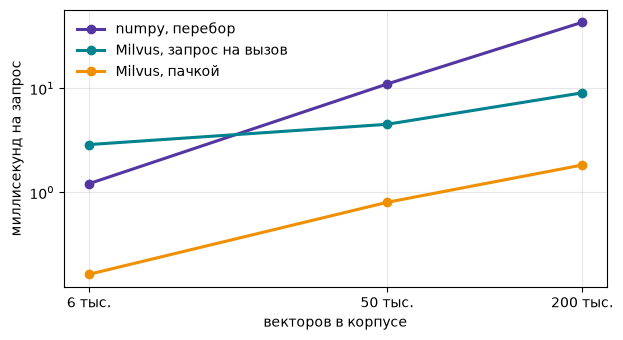

In [44]:
def inflate(vectors, n, noise=0.35, seed=0):
    rng = np.random.default_rng(seed)
    extra = vectors[rng.integers(0, len(vectors), n - len(vectors))]
    extra = extra + noise * rng.standard_normal(extra.shape, dtype=np.float32) / np.sqrt(vectors.shape[1])
    return np.vstack([vectors, extra / np.linalg.norm(extra, axis=1, keepdims=True)])

def wait_index(name, seconds=180):
    for _ in range(seconds):
        info = client.describe_index(name, "vector")
        if info.get("state") == "Finished" and info.get("pending_index_rows", 0) == 0:
            return True
        time.sleep(1)
    return False

scale_rows = []
for n in (len(line_vecs), 50_000, 200_000):
    big = inflate(line_vecs, n)
    if client.has_collection("scale"):
        client.drop_collection("scale")
    client.create_collection("scale", dimension=big.shape[1], metric_type="COSINE")
    for i in range(0, n, 5000):
        client.insert("scale", [{"id": i + j, "vector": v} for j, v in enumerate(big[i:i + 5000].tolist())])
    client.flush("scale")
    wait_index("scale")
    client.search("scale", data=[q_vecs[0].tolist()], limit=5)
    probe = q_vecs[:50]
    scale_rows.append({"векторов": n,
                       "numpy, перебор": per_query_ms(lambda: [search_numpy(q, big, 5) for q in probe], 50),
                       "Milvus, запрос на вызов": per_query_ms(lambda: [client.search("scale", data=[q.tolist()], limit=5) for q in probe], 50),
                       "Milvus, пачкой": per_query_ms(lambda: client.search("scale", data=probe.tolist(), limit=5), 50)})
client.drop_collection("scale")
scale = pd.DataFrame(scale_rows).set_index("векторов")
ax = scale.plot(figsize=(7, 3.6), marker="o", lw=2.2, logx=True, logy=True, color=[COLORS["violet"], COLORS["teal"], COLORS["amber"]])
ax.set_xticks(list(scale.index)); ax.set_xticklabels([f"{n / 1000:.0f} тыс." for n in scale.index]); ax.minorticks_off()
ax.set_ylabel("миллисекунд на запрос"); ax.set_xlabel("векторов в корпусе"); ax.legend(frameon=False); ax.grid(alpha=0.3)
ax.figure.savefig("img/scale.png", dpi=150, bbox_inches="tight")
scale.round(2)

## Спринт 5. RAG-ответ и деньги

In [45]:
RAG_SYSTEM = ("Answer the question using only the numbered sources. Cite the source number like [2]. "
              "If the sources do not contain the answer, reply exactly NOT_FOUND. The last line must be FINAL: <short answer>.")
PLAIN_SYSTEM = "Answer the question. If you do not know, reply NOT_FOUND. The last line must be FINAL: <short answer>."

In [46]:
def rag_answer(question, model, k=5, name="lines"):
    hits = search_milvus(name, question, k)
    sources = "\n".join(f"[{i + 1}] ({h['page']}) {h['text']}" for i, h in enumerate(hits))
    before = ledger.mine
    msg = chat([{"role": "system", "content": RAG_SYSTEM},
                {"role": "user", "content": f"Sources\n{sources}\n\nQuestion:{question}"}], model, tag="rag")
    return {"answer": msg.get("content") or "", "hits": hits, "cost": ledger.mine - before}


In [47]:
def plain_answer(question, model):
    before = ledger.mine
    msg = chat([{"role": "system", "content": PLAIN_SYSTEM}, {"role": "user", "content": question}], model, tag="plain")
    return {"answer": msg.get("content") or "", "hits": [], "cost": ledger.mine - before}

def final_answer(text):
    m = re.findall(r"FINAL:\s*(.+)", text or "")
    return m[-1].strip() if m else (text or "").strip()

def is_correct(task, answer):
    return f" {norm(task['answer'])} " in f" {norm(final_answer(answer))} "

def evaluate(fn, sample, config, model, workers=8):
    def one(task):
        try:
            out = fn(task["question"], model)
        except Exception as e:
            out = {"answer": f"ошибка: {e}", "hits": [], "cost": 0.0}
        return {"config": config, "model": model.split("/")[-1], "id": task["id"], "correct": is_correct(task, out["answer"]),
                "found": any(is_gold(h, task) for h in out["hits"]), "refused": "NOT_FOUND" in out["answer"],
                "cost": out["cost"], "answer": final_answer(out["answer"])[:60], "gold": task["answer"]}
    with ThreadPoolExecutor(workers) as pool:
        return pd.DataFrame(list(pool.map(one, sample)))

def report(results):
    g = results.groupby(["config", "model"], sort=False)
    table = g.agg(n=("correct", "size"), accuracy=("correct", "mean"), cost_per_task=("cost", "mean")).reset_index()
    table["cost_per_correct"] = table["cost_per_task"] / table["accuracy"].replace(0, float("nan"))
    return table.round(5)

def money_chart(table, path, baseline=None):
    fig, ax = plt.subplots(figsize=(8, 4.6))
    if baseline:
        ax.axhline(baseline[1] * 100, color=COLORS["grey"], ls="--", lw=1.2)
        ax.annotate(baseline[0], (0.01, baseline[1] * 100 + 1.5), xycoords=("axes fraction", "data"), fontsize=8, color=COLORS["grey"])
    for _, r in table.iterrows():
        color = COLORS["amber"] if "sonnet" in r["model"] else COLORS["teal"] if "haiku" in r["model"] else COLORS["violet"]
        ax.scatter(r["cost_per_task"] * 100, r["accuracy"] * 100, s=110, color=color)
        ax.annotate(f"{r['config']}\n{r['model']}", (r["cost_per_task"] * 100, r["accuracy"] * 100), fontsize=8, xytext=(7, 3), textcoords="offset points")
    ax.set_xscale("log"); ax.set_xlabel("цена вопроса, центы (логарифмическая шкала)"); ax.set_ylabel("доля верных, %"); ax.grid(alpha=0.3)
    fig.savefig(path, dpi=150, bbox_inches="tight")
    return fig

out = rag_answer(tasks[0]["question"], MODELS["cheap"])
print(out["answer"], "| эталон:", tasks[0]["answer"], "| цена, центов:", round(out["cost"] * 100, 4))

Ukraine boycotted the closing ceremony of the 2026 Winter Paralympics on 15 March [1]. 

FINAL: 15 March. | эталон: 15 March | цена, центов: 0.0062


In [48]:
sample = tasks[:40]
results = pd.concat([
    evaluate(plain_answer, sample, "без RAG", MODELS["cheap"]),
    evaluate(plain_answer, sample, "без RAG", MODELS["strong"]),
    evaluate(rag_answer, sample, "RAG, k=5", MODELS["cheap"]),
    evaluate(rag_answer, sample, "RAG, k=5", MODELS["mid"]),
    evaluate(rag_answer, sample, "RAG, k=5", MODELS["strong"]),
], ignore_index=True)
table = report(results)
table

,config,model,n,accuracy,cost_per_task,cost_per_correct
0,без RAG,gpt-4o-mini,40,0.000,0.00001,NaN
1,без RAG,claude-sonnet-4.6,40,0.025,0.00110,0.04412
2,"RAG, k=5",gpt-4o-mini,40,0.875,0.00006,0.00007
3,"RAG, k=5",claude-haiku-4.5,40,0.925,0.00066,0.00071
4,"RAG, k=5",claude-sonnet-4.6,40,0.900,0.00187,0.00208


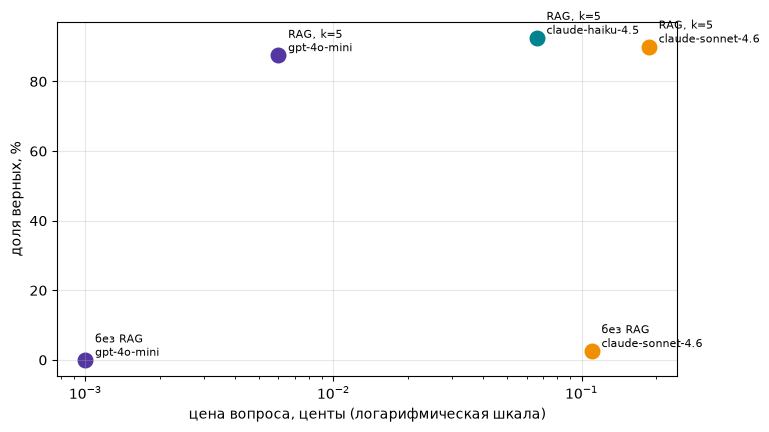

In [49]:
money_chart(table, "img/money_rag.png");

,config,model,n,accuracy,cost_per_task,cost_per_correct
0,k=1,gpt-4o-mini,40,0.800,0.00004,0.00005
1,k=3,gpt-4o-mini,40,0.850,0.00005,0.00006
2,k=5,gpt-4o-mini,40,0.875,0.00007,0.00007
3,k=10,gpt-4o-mini,40,0.875,0.00010,0.00011


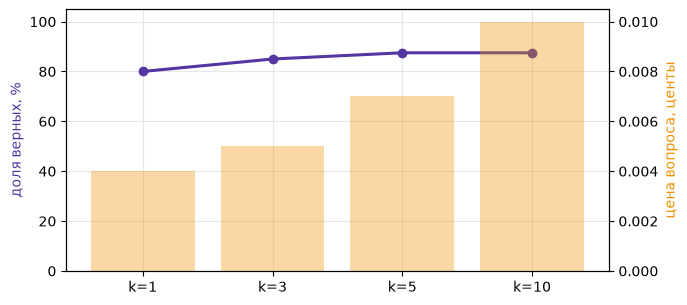

In [50]:
sweep = pd.concat([evaluate(lambda q, m, k=k: rag_answer(q, m, k), sample, f"k={k}", MODELS["cheap"]) for k in (1, 3, 5, 10)], ignore_index=True)
sweep_table = report(sweep)
fig, ax = plt.subplots(figsize=(7, 3.4))
ax.plot(sweep_table["config"], sweep_table["accuracy"] * 100, marker="o", lw=2.2, color=COLORS["violet"]); ax.set_ylabel("доля верных, %", color=COLORS["violet"])
ax2 = ax.twinx(); ax2.bar(sweep_table["config"], sweep_table["cost_per_task"] * 100, alpha=0.35, color=COLORS["amber"]); ax2.set_ylabel("цена вопроса, центы", color=COLORS["amber"])
ax.set_ylim(0, 105); ax.grid(alpha=0.3)
sweep_table

Разбор провалов

In [51]:
def diagnose(results):
    wrong = results[~results["correct"] & results["config"].str.startswith("RAG")]
    return wrong.groupby("model").agg(не_нашли=("found", lambda s: int((~s).sum())), нашли_но_ответ_неверный=("found", "sum"))

diagnose(results)

,не_нашли,нашли_но_ответ_неверный
model,,
claude-haiku-4.5,3,0
claude-sonnet-4.6,3,1
gpt-4o-mini,3,2


In [52]:
results[~results["correct"] & (results["config"] == "RAG, k=5")][["model", "gold", "answer", "found"]]

,model,gold,answer,found
82,gpt-4o-mini,Miguel Díaz-Canel,NOT_FOUND,False
85,gpt-4o-mini,two people,2,True
86,gpt-4o-mini,"4,500",NOT_FOUND,False
109,gpt-4o-mini,43,46,True
116,gpt-4o-mini,129,136,False
122,claude-haiku-4.5,Miguel Díaz-Canel,NOT_FOUND,False
126,claude-haiku-4.5,"4,500","6,650 people are reported missing after the Ne...",False
156,claude-haiku-4.5,129,At least 136 people were killed.,False
162,claude-sonnet-4.6,Miguel Díaz-Canel,Iran,False
165,claude-sonnet-4.6,two people,2,True


In [53]:
def tokens(text):
    return re.findall(r"\w+", text.lower())

def build_keyword_index(texts):
    docs = [set(tokens(text)) for text in texts]
    df = {}
    for d in docs:
        for w in d:
            df[w] = df.get(w, 0) + 1
    return docs, {w: np.log(len(docs) / n) for w, n in df.items()}

def keyword_search(query, docs, idf, k=20):
    q = set(tokens(query))
    scores = np.array([sum(idf.get(w, 0.0) for w in q & d) for d in docs])
    return [int(i) for i in np.argsort(-scores)[:k]]

In [54]:
def rrf(rankings, k=5, K=60):
    scores = {}
    for ranking in rankings:
        for rank, idx in enumerate(ranking):
            scores[idx] = scores.get(idx, 0.0) + 1 / (K + rank + 1)

    return sorted(scores, key=scores.get, reverse=True)[:k]
        


,нарезка,поиск,recall@1,recall@5
0,по 400 символов,только вектор,0.48,0.73
1,по 400 символов,только слова,0.70,0.83
2,по 400 символов,гибрид RRF,0.64,0.83
3,по строкам,только вектор,0.81,0.91
4,по строкам,только слова,0.83,0.90
5,по строкам,гибрид RRF,0.83,0.92


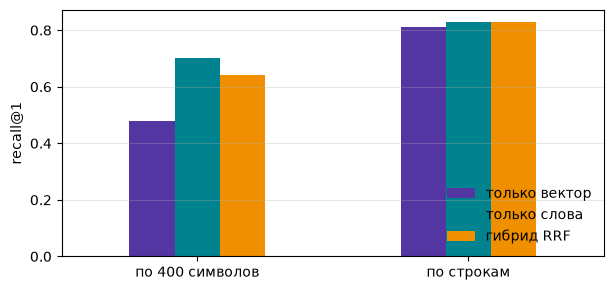

In [55]:
def recall_of(rankings, chunks, k=5):
    return float(np.mean([any(is_gold(chunks[i], t) for i in r[:k]) for r, t in zip(rankings, tasks)]))

rows = []
for cut, chunks, vectors, texts in [("по 400 символов", char_chunks, char_vecs, [c["text"] for c in char_chunks]),
                                    ("по строкам", line_chunks, line_vecs, [emb_text(c) for c in line_chunks])]:
    docs, idf = build_keyword_index(texts)
    by_vector = [[i for i, _ in search_numpy(q, vectors, 20)] for q in q_vecs]
    by_words = [keyword_search(t["question"], docs, idf, 20) for t in tasks]
    by_hybrid = [rrf([v, w], 20) for v, w in zip(by_vector, by_words)]
    rows += [{"нарезка": cut, "поиск": name, "recall@1": recall_of(r, chunks, 1), "recall@5": recall_of(r, chunks, 5)}
             for name, r in [("только вектор", by_vector), ("только слова", by_words), ("гибрид RRF", by_hybrid)]]
hybrid = pd.DataFrame(rows).round(2)
ax = hybrid.pivot(index="нарезка", columns="поиск", values="recall@1")[["только вектор", "только слова", "гибрид RRF"]].plot.bar(
    figsize=(7, 3.2), color=[COLORS["violet"], COLORS["teal"], COLORS["amber"]], rot=0)
ax.set_ylabel("recall@1"); ax.set_xlabel(""); ax.legend(frameon=False, loc="lower right"); ax.grid(alpha=0.3, axis="y")
hybrid

In [70]:
hybrid_pivot = hybrid.pivot(index="поиск", columns="нарезка", values="recall@1") \
                     [["по строкам", "по 400 символов"]]
hybrid_pivot

нарезка,по строкам,по 400 символов
поиск,,
гибрид RRF,0.83,0.64
только вектор,0.81,0.48
только слова,0.83,0.70


In [56]:
UNANSWERABLE = ["Who won the Nobel Prize in Literature announced in October 2026?", "Which team won the 2026 World Series in baseball?",
                "Who won the 2026 Formula One World Drivers' Championship?", "Which country won the Eurovision Song Contest 2027?",
                "Who won the United States Senate election in Maine held on November 3, 2026?", "Which film won the Palme d'Or at the 2027 Cannes Film Festival?",
                "What was the magnitude of the earthquake that struck Lisbon in December 2026?", "Who won the Nobel Peace Prize announced in October 2026?",
                "Which company first reached a ten trillion dollar valuation in November 2026?", "Who won the 2026 World Chess Championship match in December 2026?"]
refusals = [rag_answer(q, MODELS["cheap"]) for q in UNANSWERABLE]
sum("NOT_FOUND" in r["answer"] for r in refusals), [final_answer(r["answer"])[:40] for r in refusals if "NOT_FOUND" not in r["answer"]]

(10, [])

(0.747, 0.567)

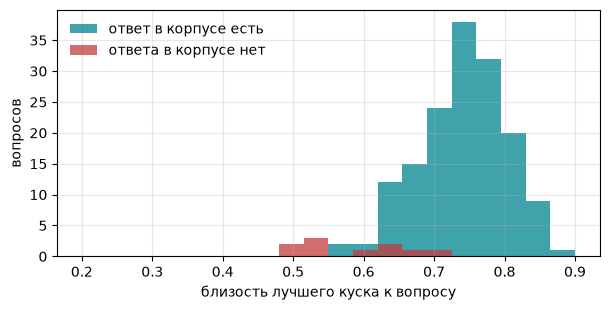

In [57]:
top_answerable = [search_numpy(q, line_vecs, 1)[0][1] for q in q_vecs]
top_unanswerable = [r["hits"][0]["score"] for r in refusals]
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.hist(top_answerable, bins=20, range=(0.2, 0.9), alpha=0.75, color=COLORS["teal"], label="ответ в корпусе есть")
ax.hist(top_unanswerable, bins=20, range=(0.2, 0.9), alpha=0.75, color=COLORS["red"], label="ответа в корпусе нет")
ax.set_xlabel("близость лучшего куска к вопросу"); ax.set_ylabel("вопросов"); ax.legend(frameon=False); ax.grid(alpha=0.3)
round(float(np.median(top_answerable)), 3), round(float(np.median(top_unanswerable)), 3)

Память агента

In [58]:
FACTS_SYSTEM = ("Ты ведёшь память ассистента о пользователе. Верни один JSON-объект вида {\"facts\": [\"...\"]}: полный обновлённый список "
                "коротких фактов о пользователе. Добавь новые устойчивые факты: имя, город, работа, интересы, пожелания к ответам. "
                "Если новый факт отменяет старый, замени старый. Разовые вопросы и мелочи не записывай.")
ASSISTANT_SYSTEM = ("Ты помощник, который отвечает на вопросы о событиях 2026 года по базе знаний. Отвечай на языке пользователя, "
                    "опирайся на источники и на то, что знаешь о пользователе. Источники подобраны автоматически и могут быть не по теме: "
                    "используй только те, что относятся к вопросу. Если в источниках ответа нет, так и скажи.")
JOURNAL, FACTS_FILE = Path("episodes.jsonl"), Path("facts.json")

class Facts(BaseModel):
    facts: list[str] = Field(description="короткие факты о пользователе")

def json_from(text):
    m = re.search(r"\{.*\}", text or "", re.S)
    cleaned = re.sub(r'(\\["\\/bfnrtu])|\\', lambda e: e.group(1) or "\\\\", m.group(0) if m else "{}")
    return json.loads(cleaned, strict=False)

def known_facts():
    return json.loads(FACTS_FILE.read_text(encoding="utf-8")) if FACTS_FILE.exists() else []

def store_facts(facts):
    FACTS_FILE.write_text(json.dumps(facts, ensure_ascii=False, indent=1), encoding="utf-8")
    if facts:
        index_to_milvus("facts", [{"page": "memory", "section": "", "url": "", "text": f} for f in facts], embed_cached(facts))

def remember_episode(session, role, text):
    with JOURNAL.open("a", encoding="utf-8") as f:
        f.write(json.dumps({"session": session, "time": time.strftime("%Y-%m-%d %H:%M:%S"), "role": role, "text": text}, ensure_ascii=False) + "\n")

for path in (JOURNAL, FACTS_FILE):
    path.unlink(missing_ok=True)
if client.has_collection("facts"):
    client.drop_collection("facts")

In [59]:
def extract_facts(dialog, known):
    prompt = f"Известные факты: {json.dumps(known, ensure_ascii=False)}\n\nДиалог:\n{dialog}"
    msg = chat([{"role": "system", "content": FACTS_SYSTEM}, {"role": "user", "content": prompt}], MODELS['cheap'], tag="memory")
    return Facts.model_validate(json_from(msg["content"])).facts
    


In [60]:
def recall_facts(question, k=3):
    if not client.has_collection("facts"):
        return []
    return [h["text"] for h in search_milvus("facts", question, k)]


In [61]:
def search_with_memory(user_text, facts, k=5):
    plain = search_milvus("lines", user_text, k)
    personal = search_milvus("lines", user_text + " " + " ".join(facts), k) if facts else []
    by_id = {h["id"]: h for h in plain + personal}
    return [by_id[i] for i in rrf([[h["id"] for h in plain], [h["id"] for h in personal]], k)]

def talk(session, history, user_text, mode="память"):
    remember_episode(session, "user", user_text)
    facts = recall_facts(user_text) if mode == "память" else []
    hits = search_with_memory(user_text, facts) if "?" in user_text else []
    sources = "\n".join(f"[{i + 1}] ({h['page']}) {h['text']}" for i, h in enumerate(hits)) or "нет"
    system = ASSISTANT_SYSTEM + ("\nЧто известно о пользователе: " + "; ".join(facts) if facts else "")
    window = history[-4:] if mode == "память" else history
    msg = chat([{"role": "system", "content": system}] + window + [{"role": "user", "content": f"Источники:\n{sources}\n\n{user_text}"}],
               MODELS["cheap"], tag=f"dialog: {mode}")
    answer = msg.get("content") or ""
    history += [{"role": "user", "content": user_text if mode == "память" else f"Источники:\n{sources}\n\n{user_text}"}, {"role": "assistant", "content": answer}]
    remember_episode(session, "assistant", answer)
    return answer

def end_session(history):
    dialog = "\n".join(f"{m['role']}: {m['content'][:400]}" for m in history)
    store_facts(extract_facts(dialog, known_facts()))
    return known_facts()

In [62]:
first = []
print(talk("s1", first, "Привет! Я Сергей, дата-аналитик из Москвы. Слежу за футболом и транзакциями, отвечай коротко."))
print(talk("s1", first, "Что было в экономике РФ в конце сентября 2026?"))
end_session(first)

Привет, Сергей! Какой вопрос о событиях 2026 года тебя интересует?
В конце сентября 2026 года в России прошли выборы, включая региональные и законодательные. Однако конкретной информации о состоянии экономики в этот период в доступных источниках нет. Известно, что в июле 2026 года США ввели 12.5% тариф на российские товары, что могло повлиять на экономическую ситуацию, но подробностей о последствиях в сентябре нет.


['Имя: Сергей',
 'Город: Москва',
 'Работа: дата-аналитик',
 'Интересы: футбол, транзакции',
 'Пожелания к ответам: отвечай коротко']

In [63]:
second = []
print(talk("s2", second, "Что интересного случилось в моих темах за лето?"))
print(talk("s2", second, "Теперь меня интересуют не транзакции, а политика"))
print(talk("s2", second, "Назови имя премьер-министра Канады?"))
end_session(second)

Летом 2026 года пройдет 2026 FIFA World Cup с 11 июня по 19 июля, который будет совместно проведен в США, Канаде и Мексике. Это значительное событие в мире футбола. Также с 5 по 27 сентября пройдет 2026 FIFA U-20 Women's World Cup в Польше, что также может быть интересно.
К сожалению, у меня нет информации о политических событиях лета 2026 года. Если у вас есть конкретные вопросы или темы, которые вас интересуют, дайте знать!
На основании источников, имя премьер-министра Канады в 2026 году не указано. Если вам нужна дополнительная информация, дайте знать!


['Имя: Сергей',
 'Город: Москва',
 'Работа: дата-аналитик',
 'Интересы: футбол, политика',
 'Пожелания к ответам: отвечай коротко']

,prompt,cost
tag,,
dialog: память,4700,0.00095
dialog: вся история,15764,0.00184


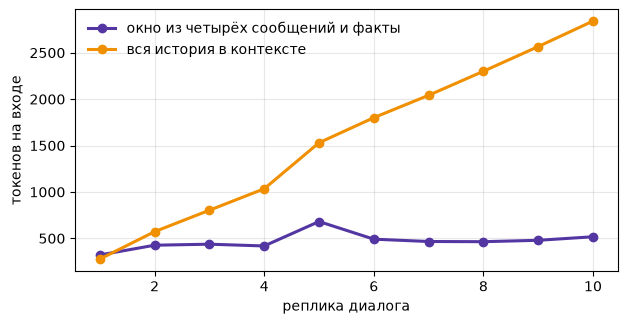

In [64]:
SCRIPT = [t["question"] for t in tasks[40:50]]
for mode in ("память", "вся история"):
    history = []
    for q in SCRIPT:
        talk("bench", history, q, mode)
per_turn = pd.DataFrame([c for c in ledger.calls if c["tag"].startswith("dialog: ")][-2 * len(SCRIPT):])
fig, ax = plt.subplots(figsize=(7, 3.4))
for (tag, part), color in zip(per_turn.groupby("tag", sort=False), [COLORS["violet"], COLORS["amber"]]):
    ax.plot(range(1, len(part) + 1), part["prompt"].values, marker="o", lw=2.2, color=color,
            label={"dialog: память": "окно из четырёх сообщений и факты", "dialog: вся история": "вся история в контексте"}[tag])
ax.set_xlabel("реплика диалога"); ax.set_ylabel("токенов на входе"); ax.legend(frameon=False); ax.grid(alpha=0.3)
fig.savefig("img/memory_tokens.png", dpi=150, bbox_inches="tight")
per_turn.groupby("tag", sort=False).agg(prompt=("prompt", "sum"), cost=("cost", "sum")).round(5)

## Поиск как инструмент агента

In [65]:
TOOLS = {}

def register(fn, args_model, description):
    TOOLS[fn.__name__] = {"fn": fn, "args": args_model, "schema": {"type": "function", "function": {
        "name": fn.__name__, "description": description, "parameters": args_model.model_json_schema()}}}

def run_tool(call):
    name = call["function"]["name"]
    try:
        spec = TOOLS[name]
        result = spec["fn"](**spec["args"].model_validate_json(call["function"]["arguments"]).model_dump())
    except Exception as e:
        result = f"ошибка инструмента {name}: {e}"
    return {"role": "tool", "tool_call_id": call["id"], "content": str(result)[:3000]}

AGENT_SYSTEM = ("You answer questions about events of 2026. Never answer from memory: look facts up with the tools, do not repeat the same call. "
                "When done, write the last line as FINAL: <short answer>, or NOT_FOUND if the knowledge base has no answer.")

def agent(question, model, max_steps=6):
    messages, seen, before = [{"role": "system", "content": AGENT_SYSTEM}, {"role": "user", "content": question}], set(), ledger.mine
    schemas = [t["schema"] for t in TOOLS.values()]
    for step in range(max_steps):
        msg = chat(messages, model, tools=schemas, tag="agent")
        messages.append(msg)
        calls = msg.get("tool_calls") or []
        keys = {(c["function"]["name"], c["function"]["arguments"]) for c in calls}
        if not calls or keys & seen or step == max_steps - 1:
            break
        seen |= keys
        messages += [run_tool(c) for c in calls]
    if calls:
        messages += [{"role": "tool", "tool_call_id": c["id"], "content": "call rejected: answer from what you already have"} for c in calls]
        msg = chat(messages, model, tag="agent")
    searches = sum(m.get("role") == "tool" for m in messages if isinstance(m, dict))
    return {"answer": msg.get("content") or "", "hits": [], "cost": ledger.mine - before, "searches": searches}

class KBArgs(BaseModel):
    query: str = Field(description="short search query in English: names, dates, key terms of the event")
    page: str = Field(default="", description="optional exact page title to search within, for example '2026 in Japan'; empty means all pages")

In [66]:
def knowledge_base(query: str, page: str = "") -> str:
    hits = search_milvus("lines", query, 5, f'page == "{page}"' if page else "")
    if not hits:
        return "nothing found"
    return "\n".join(f"[{h['page']} / {h['section']}] {h['text']}" for h in hits)


In [67]:
register(knowledge_base, KBArgs, "Searches the local knowledge base of 2026 events and returns the five closest facts with their page and section")
out = agent(tasks[3]["question"], MODELS["cheap"])
print(out["answer"], "| эталон:", tasks[3]["answer"], "| обращений к базе:", out["searches"], "| цена, центов:", round(out["cost"] * 100, 4))

In March 2026, Ukraine and Romania signed a strategic partnership agreement in the defense and energy sectors. 

FINAL: strategic partnership agreement in defense and energy sectors | эталон: a strategic partnership agreement | обращений к базе: 1 | цена, центов: 0.0118


,config,model,n,accuracy,cost_per_task,cost_per_correct
0,"RAG, k=5",gpt-4o-mini,40,0.875,0.00006,0.00007
1,агент с инструментом,gpt-4o-mini,40,0.850,0.00016,0.00019


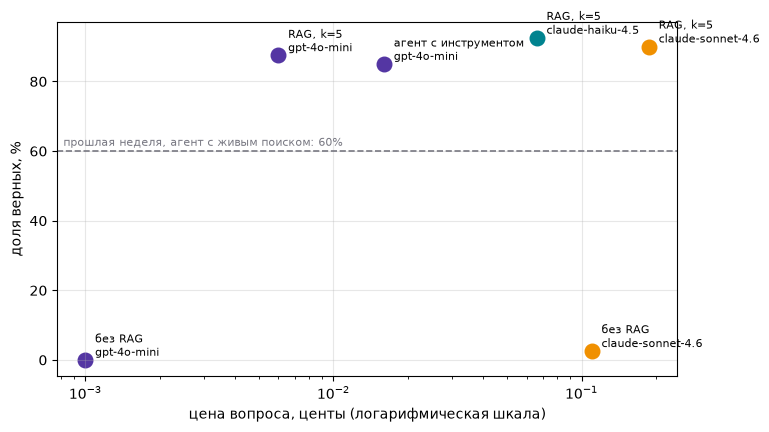

In [68]:
agent_results = evaluate(agent, sample, "агент с инструментом", MODELS["cheap"])
always = results[(results["config"] == "RAG, k=5") & (results["model"] == "gpt-4o-mini")]
final_table = report(pd.concat([results, agent_results], ignore_index=True))
last_week = float(np.mean([t["agent_ok"] for t in sample]))
money_chart(final_table, "img/money_all.png", baseline=(f"прошлая неделя, агент с живым поиском: {last_week:.0%}", last_week))
report(pd.concat([always, agent_results], ignore_index=True))

In [69]:
ledger.table(), round(ledger.total, 3)

(                                            calls  prompt  completion     cost
 tag                 model                                                     
 agent               gpt-4o-mini                89   31711        2878  0.00641
 dialog: вся история gpt-4o-mini                10   15764         400  0.00184
 dialog: память      gpt-4o-mini                15    6167         663  0.00132
 embed               text-embedding-3-small     75    1672           0  0.00003
 memory              gpt-4o-mini                 2     621         100  0.00015
 plain               claude-sonnet-4.6          40    2296        2482  0.04412
                     gpt-4o-mini                40    2254         368  0.00056
 rag                 claude-haiku-4.5           40   13285        2605  0.02631
                     claude-sonnet-4.6          40   13325        2319  0.07476
                     gpt-4o-mini               211   60580        6767  0.01315,
 0.169)